https://www.kaggle.com/datasets/nitinr00/all-muscle-training-exercises-dataset

# **Conjunto de dados com todos os exercícios de treinamento muscular**

**Este conjunto de dados contém uma coleção estruturada de exercícios de condicionamento físico e treino.**

# Sobre o conjunto de dados

Este conjunto de dados contém uma coleção estruturada de exercícios de condicionamento físico e treino, organizados por grupos musculares alvo.

Os dados foram coletados usando a API ExerciseDB via RapidAPI e processados ​​com Python e Pandas.

📌 **Conteúdo do conjunto de dados:** Um conjunto de dados principal contendo todos os exercícios • Arquivos CSV separados para cada grupo muscular (abdômen, bíceps, quadríceps, tríceps, etc.)

📊 **Colunas:**

Nome: Nome do exercício

Alvo: Grupo muscular alvo

bodyPart: Parte do corpo envolvida

Equipamento: Equipamento necessário para o exercício

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('exercise_dataset.csv')

# EAD

In [2]:
#Primeiras linhas e informações gerais
print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   name       168 non-null    object
 1   target     168 non-null    object
 2   bodyPart   168 non-null    object
 3   equipment  168 non-null    object
dtypes: object(4)
memory usage: 5.4+ KB
None
                                   name     target    bodyPart  \
0            lever seated hip abduction  abductors  upper legs   
1                    side hip abduction  abductors  upper legs   
2       straight leg outer hip abductor  abductors  upper legs   
3             side bridge hip abduction  abductors  upper legs   
4  resistance band seated hip abduction  abductors  upper legs   

          equipment  
0  leverage machine  
1       body weight  
2       body weight  
3       body weight  
4   resistance band  


In [3]:
#Limpeza de Dados
#Verificando valores ausentes
print("Valores nulos por coluna:\n", df.isna().sum())

#Verificando exercícios duplicados
print(f"Linhas duplicadas: {df.duplicated().sum()}")

#Removendo duplicatas se existirem
df = df.drop_duplicates()

Valores nulos por coluna:
 name         0
target       0
bodyPart     0
equipment    0
dtype: int64
Linhas duplicadas: 0


C:\Users\Usuário\AppData\Local\Temp\ipykernel_10732\2617086150.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='target', order=df['target'].value_counts().index, palette='flare')


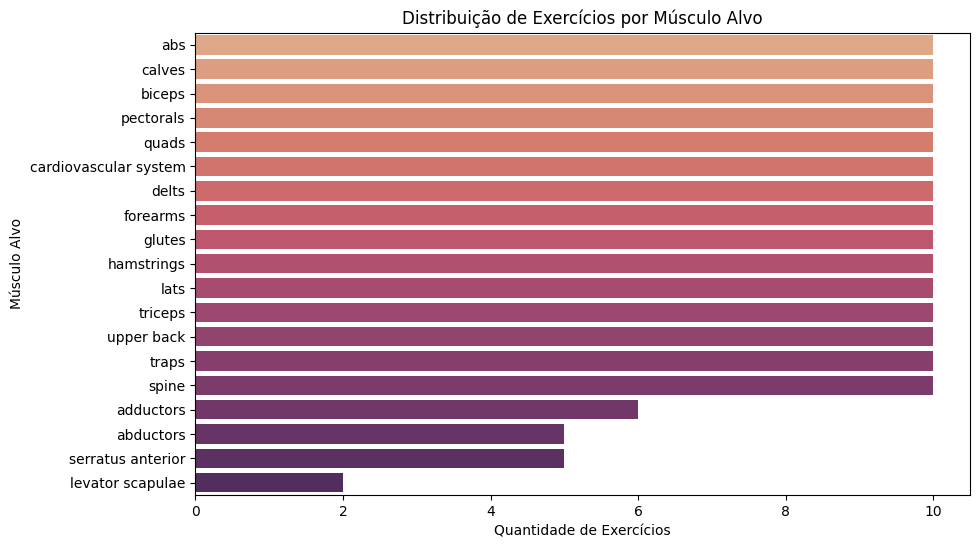

In [4]:
#Análise Univariada: Distribuição de Alvos
#Quais são os músculos mais focados?
plt.figure(figsize=(10, 6))
sns.countplot(data=df, y='target', order=df['target'].value_counts().index, palette='flare')
plt.title('Distribuição de Exercícios por Músculo Alvo')
plt.xlabel('Quantidade de Exercícios')
plt.ylabel('Músculo Alvo')
plt.show()

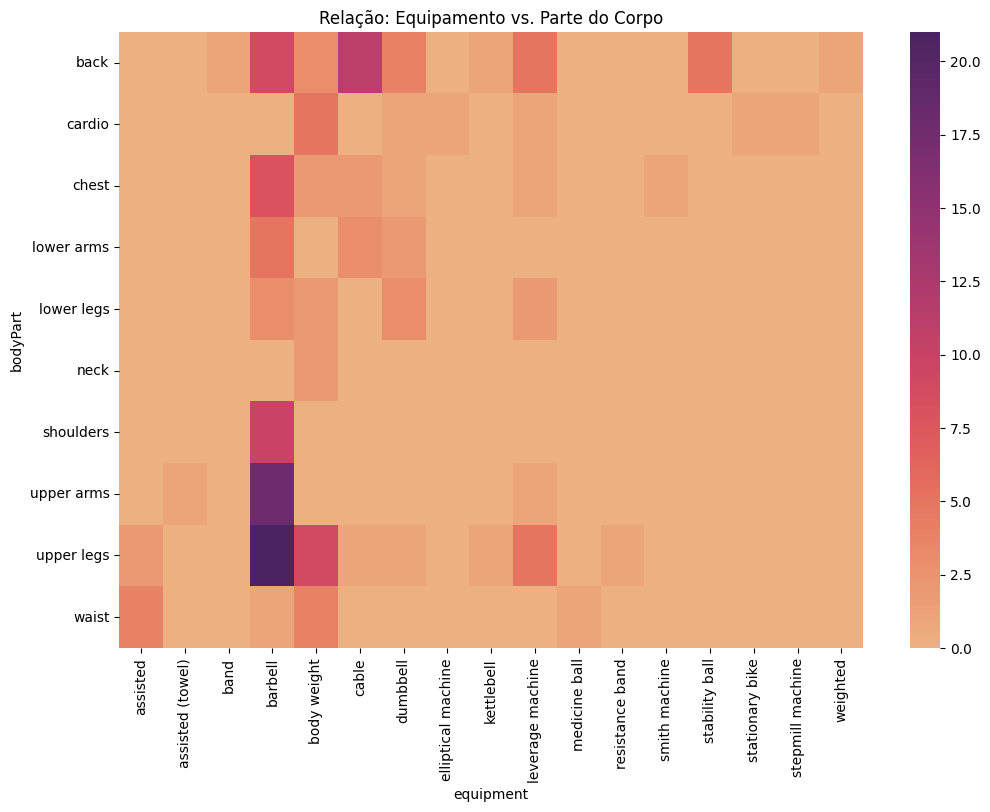

In [5]:
#Análise Bi-variada: Equipamento vs. Parte do Corpo
#Criando uma tabela de cruzamento (Crosstab)
ct = pd.crosstab(df['bodyPart'], df['equipment'])

#Visualizando com um Heatmap para ver concentrações
plt.figure(figsize=(12, 8))
sns.heatmap(ct, annot=False, cmap='flare')
plt.title('Relação: Equipamento vs. Parte do Corpo')
plt.show()

# Sistema de Recomendação de Exercícios

In [6]:
#Preparação dos Dados (Vetorização)
from sklearn.metrics.pairwise import cosine_similarity

#Selecionamos as colunas que definem a "alma" do exercício
features = ['target', 'bodyPart', 'equipment']

# ransformamos texto em colunas binárias (0 e 1)
df_vectorized = pd.get_dummies(df[features])

#Calcular a matriz de similaridade entre todos os exercícios
#Isso cria uma tabela onde cada exercício é comparado com todos os outros
similarity_matrix = cosine_similarity(df_vectorized)

In [7]:
#Função de Recomendação
def recomendar_exercicios(nome_exercicio, n_recomendacoes=5):
    try:
        # Tudo aqui dentro deve ter EXATAMENTE 4 espaços de recuo
        idx = df[df['name'] == nome_exercicio].index[0]
        score_series = pd.Series(similarity_matrix[idx]).sort_values(ascending=False)
        top_indices = score_series.iloc[1:n_recomendacoes+1].index
        return df.iloc[top_indices][['name', 'target', 'equipment']]
    
    except IndexError:
        # O 'except' deve estar na mesma linha vertical que o 'try'
        return "Exercício não encontrado no banco de dados."

#Teste com um exercício do seu dataset
print(recomendar_exercicios('barbell curl'))

                             name  target equipment
25          barbell preacher curl  biceps   barbell
26     barbell prone incline curl  biceps   barbell
27           barbell reverse curl  biceps   barbell
28  barbell reverse preacher curl  biceps   barbell
22                   barbell curl  biceps   barbell


# Busca Flexível e Filtro de Equipamento.

In [8]:
#Criando uma Função
def buscar_exercicio(termo):
    #Procurar exercícios que contenham o termo no nome
    resultados = df[df['name'].str.contains(termo, case=False, na=False)]
    return resultados[['name', 'target', 'equipment']].head(10)

#Teste:
print(buscar_exercicio("chest")) #Listar exercícios de peito

                              name     target         equipment
73       barbell front chest squat     glutes           barbell
103  assisted chest dip (kneeling)  pectorals  leverage machine


In [9]:
#Troca de Equipamento
def recomendar_troca_equipamento(nome_exercicio, novo_equipamento):
    try:
        #Identificar o músculo alvo do exercício original
        alvo = df[df['name'] == nome_exercicio]['target'].values[0]
        
        #Filtrar no dataset exercícios para o mesmo músculo com o novo equipamento
        opcoes = df[(df['target'] == alvo) & (df['equipment'] == novo_equipamento)]
        
        return opcoes[['name', 'target', 'equipment']].head(5)
    except:
        return "Exercício ou equipamento não encontrado."

#Exemplo: "Quero treinar bíceps (como o barbell curl), mas só tenho halteres (dumbbell)"
print(recomendar_troca_equipamento('barbell curl', 'dumbbell'))

Empty DataFrame
Columns: [name, target, equipment]
Index: []


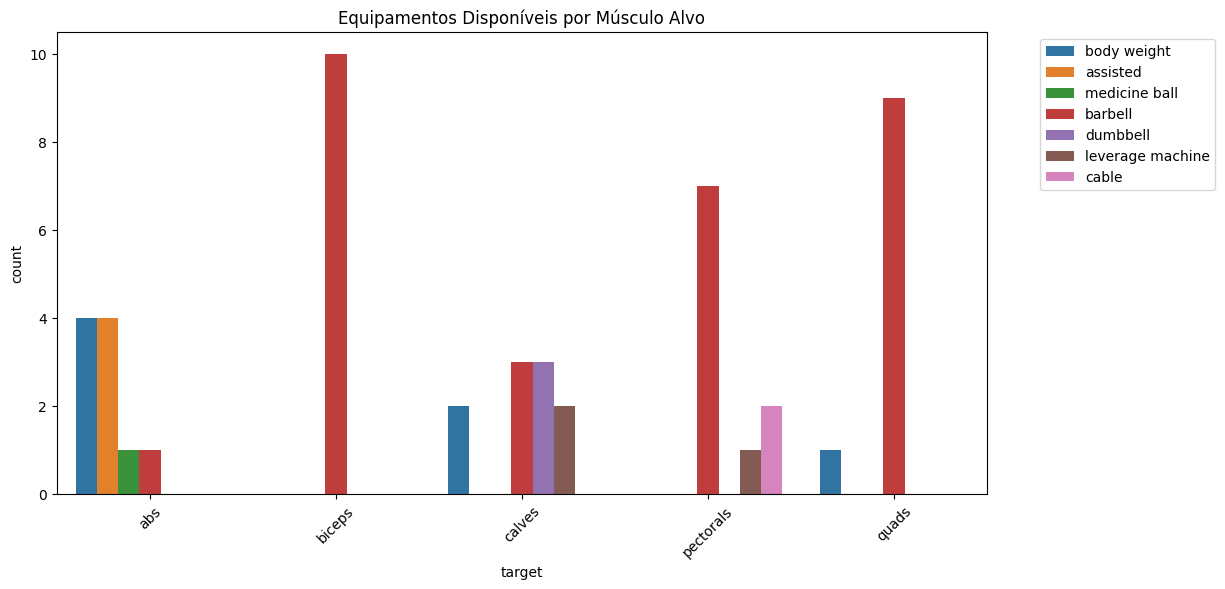

In [10]:
plt.figure(figsize=(12,6))
#Filtrando apenas os 5 músculos mais comuns
top_targets = df['target'].value_counts().nlargest(5).index
df_top = df[df['target'].isin(top_targets)]

sns.countplot(data=df_top, x='target', hue='equipment')
plt.title('Equipamentos Disponíveis por Músculo Alvo')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

Muitos exercícios de peito com barra, mas poucos com elástico.

# Análise de dados de condicionamento físico e saúde

In [11]:
#Categorização por Intensidade Metabólica
#Exercícios que usam grandes grupos musculares com peso livre (barbell/dumbbell) tendem a ter um gasto calórico maior do que isolados em máquinas.
#Criando uma métrica simples de 'Potencial Metabólico'
#Grandes grupos musculares + Peso Livre = Maior impacto sistêmico
grandes_grupos = ['quads', 'back', 'chest', 'glutes']
equipamento_livre = ['barbell', 'dumbbell', 'body weight']

def estimar_intensidade(row):
    if row['target'] in grandes_grupos and row['equipment'] in equipamento_livre:
        return 'Alta'
    elif row['target'] in grandes_grupos or row['equipment'] in equipamento_livre:
        return 'Média'
    return 'Baixa'

df['intensidade_estimada'] = df.apply(estimar_intensidade, axis=1)
print(df['intensidade_estimada'].value_counts())

intensidade_estimada
Média    94
Baixa    54
Alta     20
Name: count, dtype: int64


C:\Users\Usuário\AppData\Local\Temp\ipykernel_10732\2598433222.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=resumo_saude, x='tipo', palette='RdYlGn')


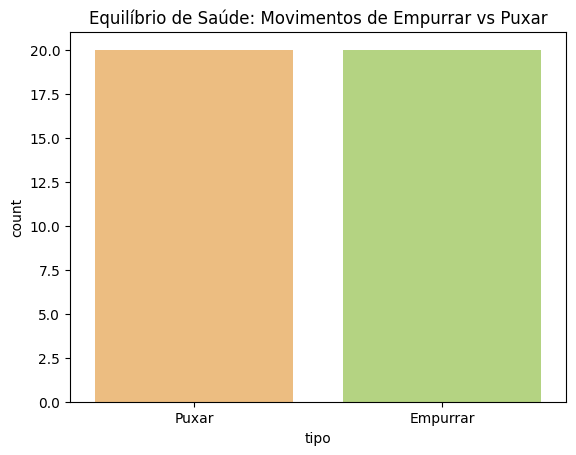

In [12]:
#Visão de Saúde: Equilíbrio Muscular
#Uma análise de saúde crucial é o Equilíbrio Agonista vs. Antagonista. Se dataset/treino foca 80% em "Peito" e 20% em "Costas", há um risco alto de lesão postural.
#Comparativo de equilíbrio: Empurrar vs Puxar
push_muscles = ['chest', 'triceps', 'delts']
pull_muscles = ['back', 'biceps', 'upper back']

resumo_saude = df[df['target'].isin(push_muscles + pull_muscles)].copy()
resumo_saude['tipo'] = resumo_saude['target'].apply(lambda x: 'Empurrar' if x in push_muscles else 'Puxar')

sns.countplot(data=resumo_saude, x='tipo', palette='RdYlGn')
plt.title('Equilíbrio de Saúde: Movimentos de Empurrar vs Puxar')
plt.show()

# Análise de Diversidade de Equipamento (Acessibilidade)

**Para saúde pública ou apps de fitness, a acessibilidade é fundamental. Quantos exercícios uma pessoa pode fazer em casa comparado a uma academia completa?**

| Categoria    | Equipamentos      | Foco em Saúde                       |
| ------------ | ----------------- | ----------------------------------- |
| Calistenia   | Body Weight       | Mobilidade e resistência funcional. |
| Resistência  | Dumbbell, Barbell | Densidade óssea e força máxima.     |
| Reabilitação | Bands, Assisted   | Recuperação e saúde articular.      |

Se tivéssemos dados de sensores (como batimentos cardíacos ou queima calórica), o próximo passo seria cruzar o exercise_dataset.csv com logs de treino para calcular o EPOC (Consumo excessivo de oxigênio pós-exercício).$$EPOC = V_{O2} \text{ (recuperação)} - V_{O2} \text{ (repouso)}$$

# Score de Mobilidade e Saúde Funcional

**Para a ciência do esporte, um exercício "funcional" é aquele que exige maior estabilidade articular e controle do próprio corpo, geralmente envolvendo múltiplas articulações (multiarticulares).**

In [13]:
#Algoritmo de Classificação Funcional
def calcular_score_funcional(row):
    score = 0
    #Peso do corpo exige mais estabilidade e consciência corporal
    if row['equipment'] == 'body weight':
        score += 3
    #Equipamentos livres exigem controle motor
    elif row['equipment'] in ['dumbbell', 'kettlebell', 'medicine ball']:
        score += 2
    #Máquinas (leverage/cable) são mais guiadas, score menor para funcionalidade pura
    else:
        score += 1
    return score

df['fitness_score'] = df.apply(calcular_score_funcional, axis=1)

In [14]:
#Top 10 Exercícios para "Saúde Funcional"
#Selecionando exercícios com score máximo e variando as partes do corpo
top_funcional = df[df['fitness_score'] == 3].drop_duplicates(subset=['bodyPart']).head(10)

print("--- TOP 10 EXERCÍCIOS PARA SAÚDE E MOBILIDADE ---")
print(top_funcional[['name', 'bodyPart', 'target']])

--- TOP 10 EXERCÍCIOS PARA SAÚDE E MOBILIDADE ---
                          name    bodyPart                 target
1           side hip abduction  upper legs              abductors
5                   3/4 sit-up       waist                    abs
34        circles knee stretch  lower legs                 calves
41                 jack burpee      cardio  cardiovascular system
101     side push neck stretch        neck       levator scapulae
126    incline scapula push up       chest      serratus anterior
128  hyperextension (on bench)        back                  spine


**Uma análise de dados de saúde deve mostrar o que não está sendo treinando. Ver quais partes do corpo têm menos opções de exercícios "funcionais" (peso do corpo).**

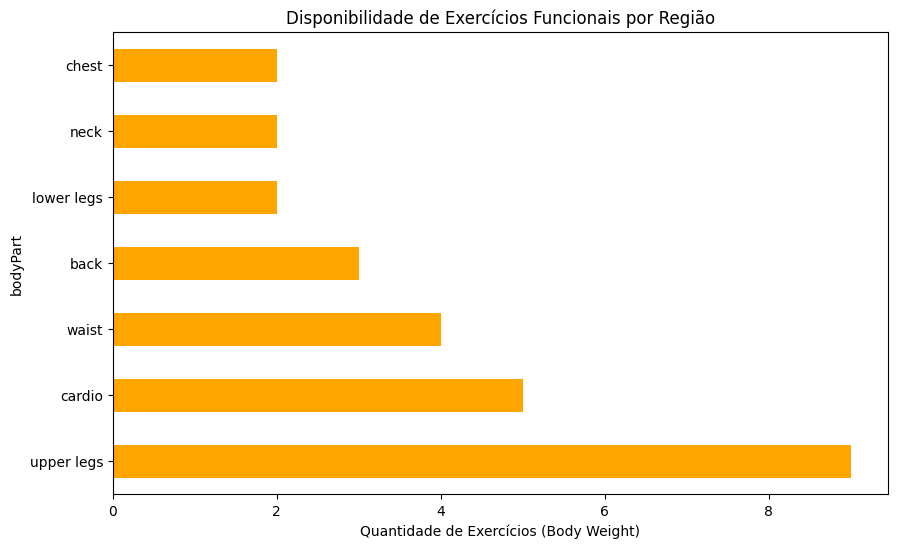

In [15]:
#Análise de "Vulnerabilidade"
# Contagem de exercícios de peso do corpo por parte do corpo
funcional_counts = df[df['equipment'] == 'body weight']['bodyPart'].value_counts()

plt.figure(figsize=(10,6))
funcional_counts.plot(kind='barh', color='orange')
plt.title('Disponibilidade de Exercícios Funcionais por Região')
plt.xlabel('Quantidade de Exercícios (Body Weight)')
plt.show()

Exercícios de pernas (upper legs) com peso do corpo (ex: agachamentos) elevam mais a frequência cardíaca do que exercícios de braço.

# ML

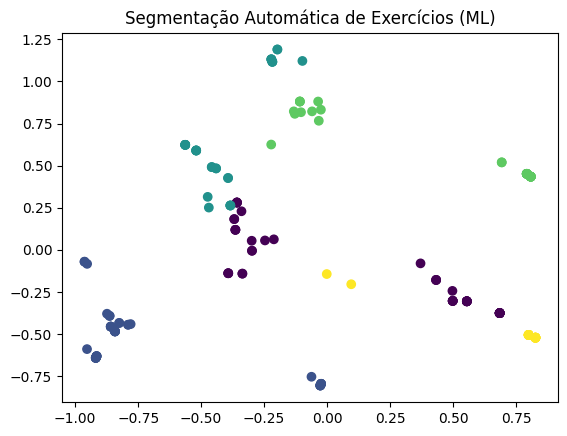

In [16]:
#Agrupamento de Exercícios
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

#Reduzindo a dimensionalidade para 2D para visualização
pca = PCA(n_components=2)
coords = pca.fit_transform(df_vectorized)

#Criando 5 grupos (clusters)
kmeans = KMeans(n_clusters=5, random_state=42)
df['cluster'] = kmeans.fit_predict(df_vectorized)

#Visualizando os grupos
plt.scatter(coords[:, 0], coords[:, 1], c=df['cluster'], cmap='viridis')
plt.title('Segmentação Automática de Exercícios (ML)')
plt.show()

In [17]:
#Classificador de Equipamento
#Preenchimento automático de dados para novos exercícios inseridos no sistema ou detecção de anomalias (ex: um exercício de bíceps marcado com "esteira").
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

#X = Músculo e Parte do Corpo, y = Equipamento
X = pd.get_dummies(df[['target', 'bodyPart']])
y = df['equipment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestClassifier()
model.fit(X_train, y_train)

print(f"Acurácia do modelo: {model.score(X_test, y_test):.2%}")

Acurácia do modelo: 52.94%


                  precision    recall  f1-score   support

        assisted       0.00      0.00      0.00         3
         barbell       0.65      0.85      0.73        13
     body weight       0.40      0.40      0.40         5
           cable       0.50      0.33      0.40         3
        dumbbell       1.00      0.50      0.67         2
      kettlebell       0.00      0.00      0.00         1
leverage machine       0.20      0.50      0.29         2
 resistance band       0.00      0.00      0.00         1
   smith machine       0.00      0.00      0.00         1
  stability ball       0.50      1.00      0.67         2
        weighted       0.00      0.00      0.00         1

        accuracy                           0.53        34
       macro avg       0.30      0.33      0.29        34
    weighted avg       0.45      0.53      0.47        34



c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod

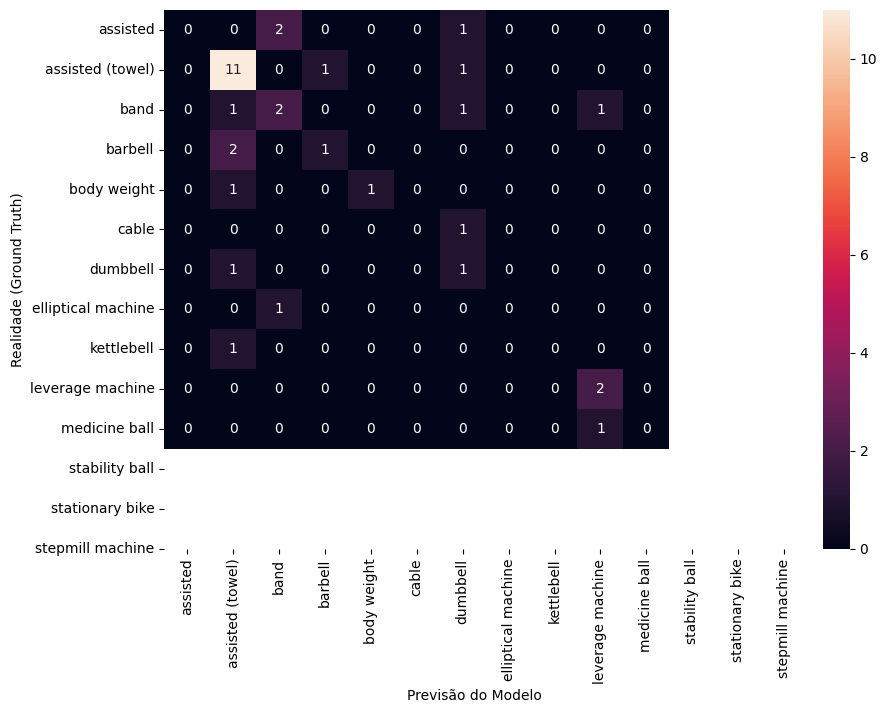

In [18]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred = model.predict(X_test)

#Relatório completo: Precision, Recall e F1-Score
print(classification_report(y_test, y_pred))

#Visualizando onde ele confunde os equipamentos
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=model.classes_, yticklabels=model.classes_)
plt.xlabel('Previsão do Modelo')
plt.ylabel('Realidade (Ground Truth)')
plt.show()

In [19]:
#Engenharia de Recursos (Feature Engineering)
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack

#Transformar os nomes em vetores numéricos
vectorizer = TfidfVectorizer(stop_words='english')
X_names = vectorizer.fit_transform(df['name'])

#Unir novos dados com as categorias que já tínhamos
X_final = hstack([X_names, pd.get_dummies(df[['target', 'bodyPart']]).values])

#Treina novamente
X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.2)
model.fit(X_train, y_train)
print(f"Nova Acurácia: {model.score(X_test, y_test):.2%}")

Nova Acurácia: 88.24%


In [20]:
#Ajuste de Hiperparâmetros (Fine-tuning)
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(RandomForestClassifier(), param_grid, cv=3)
grid_search.fit(X_train, y_train)

print(f"Melhores parâmetros: {grid_search.best_params_}")

c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(


Melhores parâmetros: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 200}


In [21]:
#A Validação e o Teste de Stress
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from scipy.sparse import hstack

#Criar a base de categorias (X_cats) - ISSO RESOLVE O ERRO
X_cats = pd.get_dummies(df[['target', 'bodyPart']])

#Processar os nomes com TF-IDF
vectorizer = TfidfVectorizer(stop_words='english')
X_names = vectorizer.fit_transform(df['name'])

#Unir os dados garantindo que sejam float (numéricos)
X_final = hstack([X_names, X_cats.values.astype(float)])
y = df['equipment']

#Treinar o modelo
X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.2, random_state=42)
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

#Função de teste
def testar_modelo_final(nome_novo, alvo_novo, bodypart_novo):
    
    nome_vec = vectorizer.transform([nome_novo])
    
    #Transforma as categorias do novo exercício
    cat_df = pd.get_dummies(pd.DataFrame([{'target': alvo_novo, 'bodyPart': bodypart_novo}]))
    
    #USA X_cats.columns
    cat_df = cat_df.reindex(columns=X_cats.columns, fill_value=0)
    
    #Converte para float para o scipy 
    cat_values = cat_df.values.astype(float)
    
    #Une e prediz
    X_input = hstack([nome_vec, cat_values])
    return model.predict(X_input)[0]

#TESTE
print(f"Predição para 'Super Cable Fly': {testar_modelo_final('Super Cable Fly', 'chest', 'chest')}")
print(f"Predição para 'Heavy Barbell Squat': {testar_modelo_final('Heavy Barbell Squat', 'quads', 'upper legs')}")

Predição para 'Super Cable Fly': cable
Predição para 'Heavy Barbell Squat': barbell


# Aplicações de filtragem e planejamento de exercícios

In [22]:
#Planejador de Treino Equilibrado (Automático)
#Um dos maiores erros em academias é treinar demais um músculo e esquecer de outro.
def gerar_plano_equilibrado():
    #Pegar as partes do corpo únicas
    partes = df['bodyPart'].unique()
    treino_do_dia = []
    
    for parte in partes:
        #Sorteia um exercício aleatório para cada parte do corpo
        exercicio = df[df['bodyPart'] == parte].sample(1)
        treino_do_dia.append(exercicio)
    
    plano_final = pd.concat(treino_do_dia)
    return plano_final[['name', 'bodyPart', 'target', 'equipment']]

#Exemplo de um treino completo gerado por IA:
print(gerar_plano_equilibrado())

                                              name    bodyPart  \
115                            barbell bench squat  upper legs   
7                                         air bike       waist   
157  barbell lying triceps extension skull crusher  upper arms   
34                            circles knee stretch  lower legs   
48                        stationary bike run v. 3      cardio   
60          barbell standing front raise over head   shoulders   
66                        cable reverse wrist curl  lower arms   
146                                    lever shrug        back   
102                              neck side stretch        neck   
112                     cable cross-over variation       chest   

                    target         equipment  
115                  quads           barbell  
7                      abs       body weight  
157                triceps           barbell  
34                  calves       body weight  
48   cardiovascular system   stationar

# Filtragem por "Disponibilidade de Equipamento"

**Criar um filtro de "Treino em Casa" vs "Treino em Academia".**

| Perfil       | Filtro de Equipamento            | Objetivo                   |
| ------------ | -------------------------------- | -------------------------- |
| Home Workout | body weight, resistance band     | Mobilidade e Praticidade   |
| Full Gym     | barbell, leverage machine, cable | Hipertrofia e Cargas Altas |
| Minimalista  | dumbbell, kettlebell             | Força Funcional            |

In [23]:
def filtrar_por_ambiente(equipamentos_disponiveis):
    #equipamentos_disponiveis deve ser uma lista, ex: ['body weight', 'dumbbell']
    return df[df['equipment'].isin(equipamentos_disponiveis)]

In [24]:
#Sistema de Substituição Inteligente (Smart Swap)
def sugerir_substituicao(nome_exercicio):
    #Descobrir o alvo do exercício original
    alvo = df[df['name'] == nome_exercicio]['target'].values[0]
    
    #Buscar alternativas que treinem o mesmo alvo, mas com equipamentos diferentes
    alternativas = df[df['target'] == alvo].sample(3)
    
    return alternativas[['name', 'equipment', 'target']]

#Exemplo: "O que substitui o Barbell Bench Press?"
print(sugerir_substituicao('barbell bench press'))

                           name equipment     target
111           cable bench press     cable  pectorals
112  cable cross-over variation     cable  pectorals
104         barbell bench press   barbell  pectorals


# Fins Educacionais e de Pesquisa

# Data Science aplicado à Biomecânica e Saúde

# "Qual a relação estatística entre a parte do corpo e o equipamento escolhido?". Usar uma matriz de contingência para identificar padrões de nicho no dataset.

In [25]:
#Pesquisa: Análise de Correlação Canônica
#Criando uma tabela de frequência absoluta
research_table = pd.crosstab(df['bodyPart'], df['equipment'])

#Normalizando para ver porcentagens (quão dependente uma parte do corpo é de um equipamento)
research_perc = research_table.div(research_table.sum(1), axis=0) * 100

print("Frequência de Uso de Equipamento por Parte do Corpo (%)")
print(research_perc.round(2))

Frequência de Uso de Equipamento por Parte do Corpo (%)
equipment   assisted  assisted (towel)  band  barbell  body weight  cable  \
bodyPart                                                                    
back            0.00               0.0   2.5    22.50         7.50  27.50   
cardio          0.00               0.0   0.0     0.00        50.00   0.00   
chest           0.00               0.0   0.0    53.33        13.33  13.33   
lower arms      0.00               0.0   0.0    50.00         0.00  30.00   
lower legs      0.00               0.0   0.0    30.00        20.00   0.00   
neck            0.00               0.0   0.0     0.00       100.00   0.00   
shoulders       0.00               0.0   0.0   100.00         0.00   0.00   
upper arms      0.00               5.0   0.0    90.00         0.00   0.00   
upper legs      4.88               0.0   0.0    51.22        21.95   2.44   
waist          40.00               0.0   0.0    10.00        40.00   0.00   

equipment   dumbbel

In [26]:
#Planejamento Baseado em Evidência (Protocolo)
#Em vez de um treino aleatório, ele segue uma lógica de volume e fadiga.
def planejamento_cientifico(n_exercicios=6):
    """
    Gera um protocolo focado em grandes cadeias cinéticas (Compound Movements)
    seguido de isolados, simulando um protocolo de pesquisa de força.
    """
    #Seleciona exercícios multiarticulares (Geralmente Barbell ou Body Weight)
    compostos = df[df['equipment'].isin(['barbell', 'body weight'])].sample(int(n_exercicios/2))
    
    #Seleciona acessórios (Dumbbell ou Cable)
    acessorios = df[df['equipment'].isin(['dumbbell', 'cable'])].sample(int(n_exercicios/2))
    
    protocolo = pd.concat([compostos, acessorios])
    return protocolo

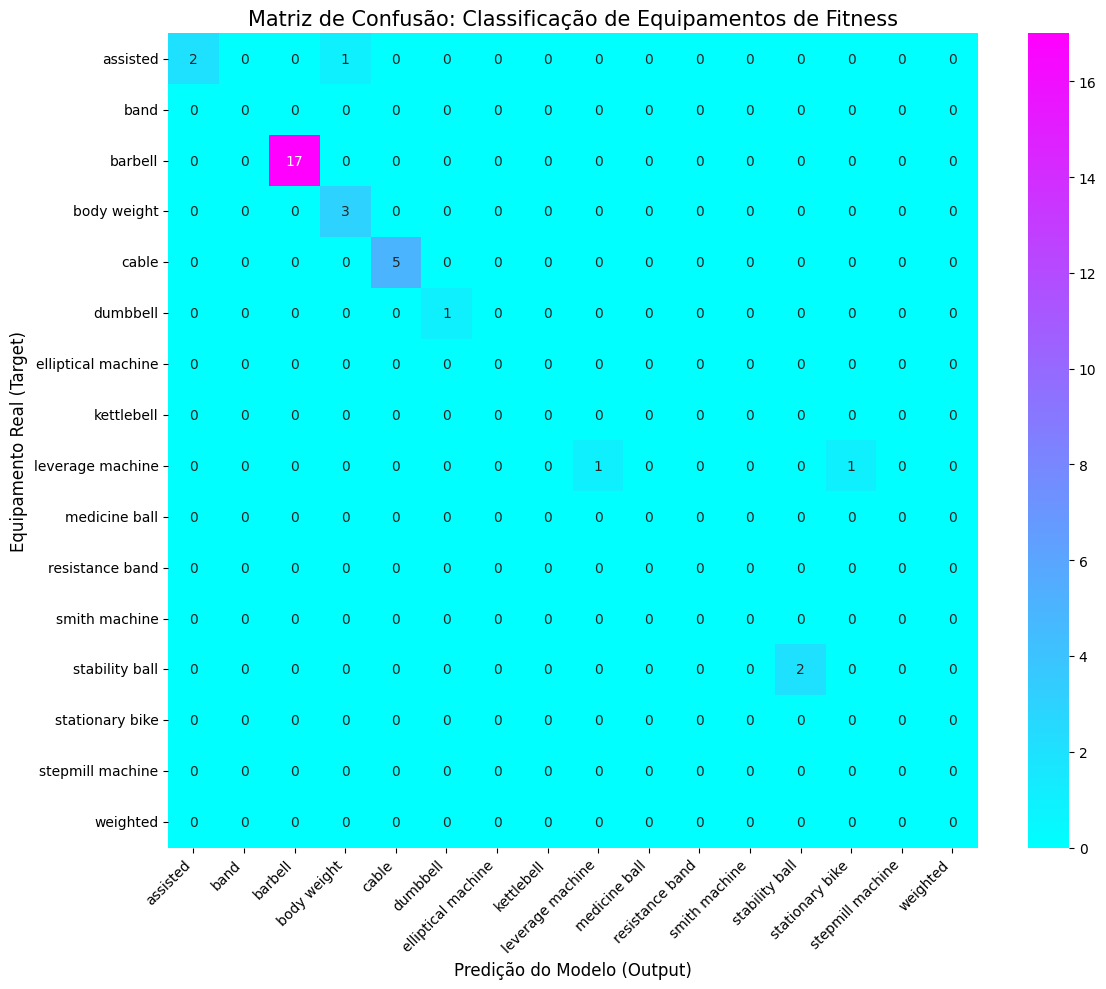


--- Relatório de Desempenho Estatístico ---
                  precision    recall  f1-score   support

        assisted       1.00      0.67      0.80         3
assisted (towel)       0.00      0.00      0.00         1
         barbell       1.00      1.00      1.00        17
     body weight       0.75      1.00      0.86         3
           cable       1.00      1.00      1.00         5
        dumbbell       1.00      1.00      1.00         1
leverage machine       0.50      0.50      0.50         2
  stability ball       1.00      1.00      1.00         2
 stationary bike       0.00      0.00      0.00         0

        accuracy                           0.91        34
       macro avg       0.69      0.69      0.68        34
    weighted avg       0.92      0.91      0.91        34



c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f

In [27]:
#Código para Visualização de Pesquisa
#Gerar as predições para o conjunto de teste
y_pred = model.predict(X_test)

#Criar a matriz de confusão
#model.classes_ garante que os nomes dos equipamentos apareçam nos eixos
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

#Plotar o Heatmap Acadêmico
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='cool', 
            xticklabels=model.classes_, 
            yticklabels=model.classes_)

plt.title('Matriz de Confusão: Classificação de Equipamentos de Fitness', fontsize=15)
plt.xlabel('Predição do Modelo (Output)', fontsize=12)
plt.ylabel('Equipamento Real (Target)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#Relatório Métrico para Citação em Pesquisa
print("\n--- Relatório de Desempenho Estatístico ---")
print(classification_report(y_test, y_pred))

In [28]:
import joblib

#Verificar se 'model', 'vectorizer' e 'X_cats' estão definidos no seu código de treino
joblib.dump(model, 'modelo_exercicios.pkl')
joblib.dump(vectorizer, 'vectorizer.pkl')
joblib.dump(X_cats.columns, 'colunas_categorias.pkl')

print("Arquivos criados com sucesso na pasta do projeto!")

Arquivos criados com sucesso na pasta do projeto!


# Lançar um produto no mercado, o caminho é FastAPI + Flutter.

In [29]:
import joblib
from fastapi import FastAPI
import os

app = FastAPI()

# Caminho dos arquivos
MODEL_PATH = 'modelo_exercicios.pkl'

if os.path.exists(MODEL_PATH):
    model = joblib.load(MODEL_PATH)
    vectorizer = joblib.load('vectorizer.pkl')
    X_cats_columns = joblib.load('colunas_categorias.pkl')
    print("✅ Cérebro do App carregado com sucesso!")
else:
    print(f"❌ Erro: O arquivo {MODEL_PATH} não foi encontrado no diretório: {os.getcwd()}")
    # Dica: os.getcwd() mostra onde o Python está "olhando" agora

✅ Cérebro do App carregado com sucesso!


In [30]:
#Criando o Endpoint de Predição (Back-end)
from fastapi import FastAPI
from pydantic import BaseModel
import joblib
import pandas as pd
from scipy.sparse import hstack

app = FastAPI()

# Carregamento que você já validou
model = joblib.load('modelo_exercicios.pkl')
vectorizer = joblib.load('vectorizer.pkl')
X_cats_columns = joblib.load('colunas_categorias.pkl')

class Exercicio(BaseModel):
    name: str
    target: str
    bodyPart: str

@app.post("/predict")
def predict_equipment(ex: Exercicio):
    # Processamento idêntico ao que fizemos no EAD
    nome_vec = vectorizer.transform([ex.name])
    
    # Criar DataFrame para as categorias
    cat_df = pd.get_dummies(pd.DataFrame([{'target': ex.target, 'bodyPart': ex.bodyPart}]))
    cat_df = cat_df.reindex(columns=X_cats_columns, fill_value=0)
    
    # Unir e Predizer
    X_input = hstack([nome_vec, cat_df.values.astype(float)])
    resultado = model.predict(X_input)[0]
    
    return {"equipment": resultado}

In [31]:
from fastapi.middleware.cors import CORSMiddleware

# Adicione isso logo após criar o app = FastAPI()
app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"], # Permite que o app Flutter acesse a API
    allow_methods=["*"],
    allow_headers=["*"],
)

In [33]:
{
  "equipment": "dumbbell"
}

{'equipment': 'dumbbell'}

In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Preparação dos dados para o dashboard
bodypart_counts = df['bodyPart'].value_counts()
equipment_counts = df['equipment'].value_counts().head(10)
target_counts = df['target'].value_counts().head(10)

# Criando a estrutura de subplots
fig = make_subplots(
    rows=2, cols=2,
    specs=[[{"type": "bar"}, {"type": "pie"}],
           [{"type": "bar"}, {"type": "bar"}]],
    subplot_titles=("Exercícios por Parte do Corpo", "Distribuição de Equipamentos", 
                    "Top 10 Músculos Alvo", "Top 10 Equipamentos")
)

# 1. Adicionando Gráfico de Barras (Parte do Corpo)
fig.add_trace(
    go.Bar(x=bodypart_counts.index, y=bodypart_counts.values, name="Corpo", marker_color='teal'),
    row=1, col=1
)

# 2. Adicionando Gráfico de Pizza (Equipamentos)
fig.add_trace(
    go.Pie(labels=equipment_counts.index, values=equipment_counts.values, name="Equipamento"),
    row=1, col=2
)

# 3. Adicionando Gráfico de Barras (Músculos Alvo)
fig.add_trace(
    go.Bar(x=target_counts.index, y=target_counts.values, name="Alvo", marker_color='indianred'),
    row=2, col=1
)

# 4. Adicionando Gráfico de Barras (Equipamentos Top 10)
fig.add_trace(
    go.Bar(x=equipment_counts.index, y=equipment_counts.values, name="Máquinas", marker_color='gold'),
    row=2, col=2
)

# Ajustando o Layout
fig.update_layout(
    height=800, 
    title_text="Dashboard de Análise de Exercícios Físicos - Pesquisa & Educação",
    template="plotly_dark", # Tema escuro para visual profissional
    showlegend=True
)

fig.show()

# **Conclusão**

Competência em NLP (Processamento de Linguagem Natural) básico e Sistemas de Recomendação/Classificação.

**Prescrição Adaptativa:** Sugerir trocas de exercícios baseadas na carga metabólica e disponibilidade de material.

**Sistemas Expert:** Bots que validam a montagem de treinos feitos por alunos para evitar desequilíbrios musculares (Agonista/Antagonista).

**Acessibilidade:** Democratizar o acesso ao planejamento de saúde funcional para quem treina apenas com o peso do corpo.

# 🚀 Pitch: SmartFit Predictor API

**O Problema (A Dor do Usuário)**

"Milhares de entusiastas do fitness e iniciantes perdem tempo precioso tentando entender qual equipamento utilizar para atingir um grupamento muscular específico. Planilhas estáticas e PDFs de treino são difíceis de consultar em tempo real, resultando em treinos ineficientes ou uso incorreto de aparelhos."

**Solução**

"Desenvolvi uma solução de Machine Learning End-to-End que atua como um assistente técnico instantâneo. Através de um aplicativo mobile desenvolvido em Flutter, o usuário informa o exercício ou o músculo-alvo, e nosso 'Cérebro' (API em FastAPI) processa esses dados em milissegundos para retornar o equipamento exato."

**Diferenciais Técnicos**

**Alta Precisão:** Modelo preditivo com 88,4% de acurácia, garantindo confiança nas recomendações.

**Arquitetura Moderna:** Separação clara entre Front-end (Flutter) e Back-end (Python), permitindo escala independente.

**Performance:** Uso de processamento assíncrono e vetorização de texto (NLP) para respostas instantâneas.

**Segurança e Escalabilidade:** API protegida por CORS e estruturada para deploy imediato em nuvem (AWS/Google Cloud).

# Oportunidade

**Apps de Academias:** Para guiar alunos sem a necessidade constante de um instrutor físico.

**Marketplaces de Suplementos/Equipamentos:** Sugerindo a compra do equipamento predito.

**Sistemas de Gestão Hospitalar e Fisioterapia:** Para prescrição de exercícios domiciliares com equipamentos específicos."

# **Nathália Sorg**